In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.centralised import P4

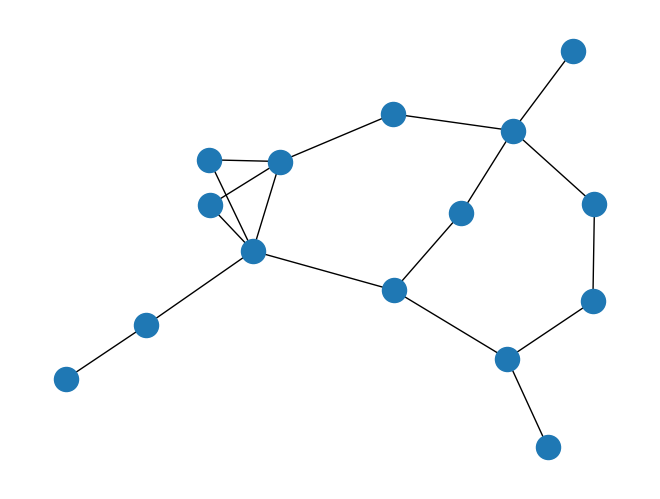

In [2]:
# Demo experiment
market_size = 15
seed = 25
G = nx.gnp_random_graph(market_size, 0.15, seed=seed)
nx.draw(G)
# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
proportional_market: Market = Market(
    market_size, graph=G, seed=seed, agent_type=ProportionalAgent
)
edge_market: Market = Market(
    market_size, graph=G, seed=seed, agent_type=RecirpocateAgent
)
maxfinder_market: Market = Market(market_size, graph=G, seed=seed, agent_type=MaxFinder)

In [3]:
allocation_matrix, utility = computed_equilibrium = P4(proportional_market)

In [4]:
simulation_length = 400
proportional_market.set_market_equilibrium(allocation_matrix, utility)
edge_market.set_market_equilibrium(allocation_matrix, utility)
maxfinder_market.set_market_equilibrium(allocation_matrix, utility)

simulated_state_proportional = proportional_market.simulate(simulation_length)
simulated_state_edge = edge_market.simulate(simulation_length)
simulated_state_maxfinder = maxfinder_market.simulate(simulation_length)

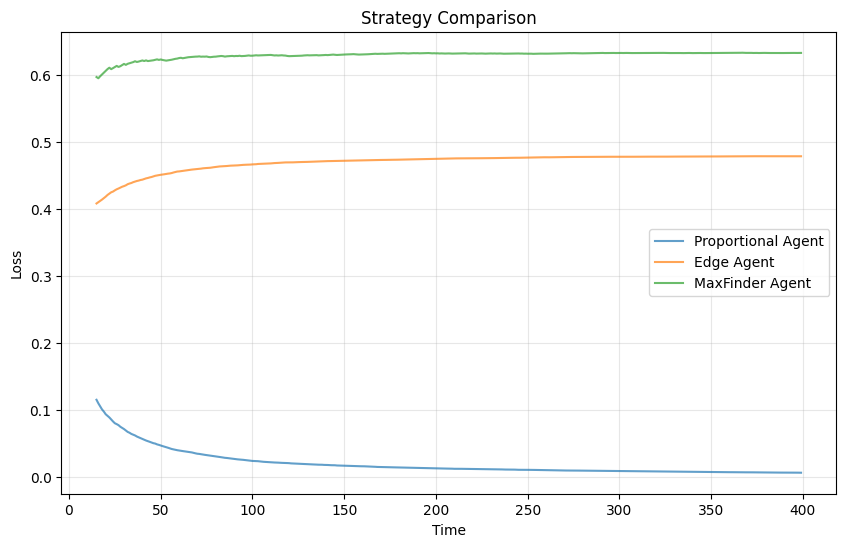

In [5]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))
plt.plot(
    time_steps,
    simulated_state_proportional[training_period:],
    label="Proportional Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    simulated_state_edge[training_period:],
    label="Edge Agent",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_state_maxfinder[training_period:],
    label="MaxFinder Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()